# The Narrative Structure of the _Popol Wuj_:<br/>A Statistical Approach

Rafael C. Alvarado | Spring 2025

# Preliminaries

## Import code libraries

In [138]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation as LDA
from sklearn.cluster import KMeans

from great_tables import GT

In [139]:
import sys; sys.path.append("../../local_lib/")

import hac
from hac import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

## Set some hyperparameters

In [140]:
px_template = 'plotly_white'

# Number of equal size chunks to divide the TOKEN table
n_chunks = 60
# n_chunks = 100

# Use if parsing strings of Mayan
# token_pattern = r"(?u)\b\w[\w']*\b"

# These are used with CounterVectorizer
min_ngram = 1
max_ngram = 1

# The limit below which words will be excluded from models
dh_thresh_agg = 'mean' # Use 'median' for much less severe cut

# Get and prepare the data

## Read in CHAP and TOKEN

In [141]:
CHAP = pd.read_csv(f"christenson-CHAP-with-text.csv").set_index("chap_num")
VOCAB = pd.read_csv(f"christenson-VOCAB.csv", index_col='term_str')
TOKEN = pd.read_csv(f"christenson-TOKEN.csv").set_index(['chap_num','line_num','token_num']).dropna()
CHUNK = pd.read_csv(f"christenson-CHUNK-{n_chunks}.csv").set_index('chunk_num')
TFIDF = pd.read_csv(f"christenson-TFIDF-{n_chunks}.csv").set_index('chunk_num')

In [142]:
CHUNK['short_label'] = CHUNK.apply(lambda x: f"[{x.name}] {x.doc_ids}", axis=1) 
# CHUNK['long_label'] = 

In [143]:
CHUNK.head()

,chunk_str,doc_ids,short_label
chunk_num,,,
0,are' u xe' ojer tzij waral k'iche' u b'i' wara...,1 2 3,[0] 1 2 3
1,ta chawaxoq ta saqiro puch apachinaq tzuqul q'...,3 4 5,[1] 3 4 5
2,k'ajolom xe'uchax k'ut xa kixjalatajik rumal m...,5 6 7,[2] 5 6 7
3,che' xe'uchaxik e aj q'ij k'ate puch u qajik u...,7 8,[3] 7 8
4,ta nab'e qa patan chiwach ix ta na winaq wakam...,8 9,[4] 8 9


## Map CHUNK to CHAP

In [144]:
# CHAP['chunk_ids'] = CHUNK_CHAP_MATRIX.stack().reset_index().groupby('chap_num').chunk_num.apply(lambda x: ','.join(map(str, x)))

In [145]:
# VOCAB = CTM.sum().to_frame('n')
# VOCAB.index.name = 'term_str'
# VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

In [146]:
VOCAB['gloss'] = None

# Hierarchical Clusters

## Create TFIDF_SIM

Cluster CHUNK docs by TFIDF.

We generate a square matrix of documents by documents showing pairwise similarities.

In [147]:
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index, columns=TFIDF.index)

**View heatmap of document clusters**

A heatmap of the same space provides some insight into the nature of the clusters.

In [148]:
# sns.clustermap?

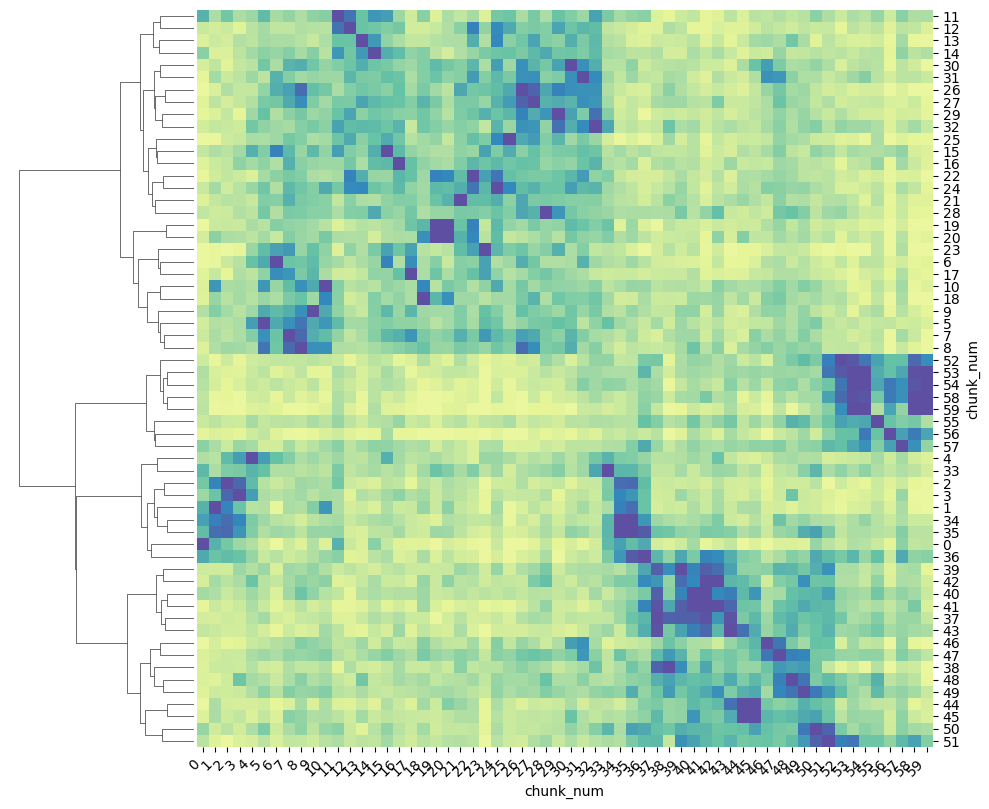

In [149]:
fig = sns.clustermap(TFIDF_SIM,
               method='ward', 
               metric='euclidean',
               cmap='Spectral', 
               center=0,
               cbar_pos=None,
               col_cluster=False, 
               robust=True, 
               # z_score=1,
               xticklabels=True,
               yticklabels=True,
                    figsize=(10,10))
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
plt.xticks(rotation=45)
fig.ax_col_dendrogram.set_visible(False)
plt.show()

## Generate HAC

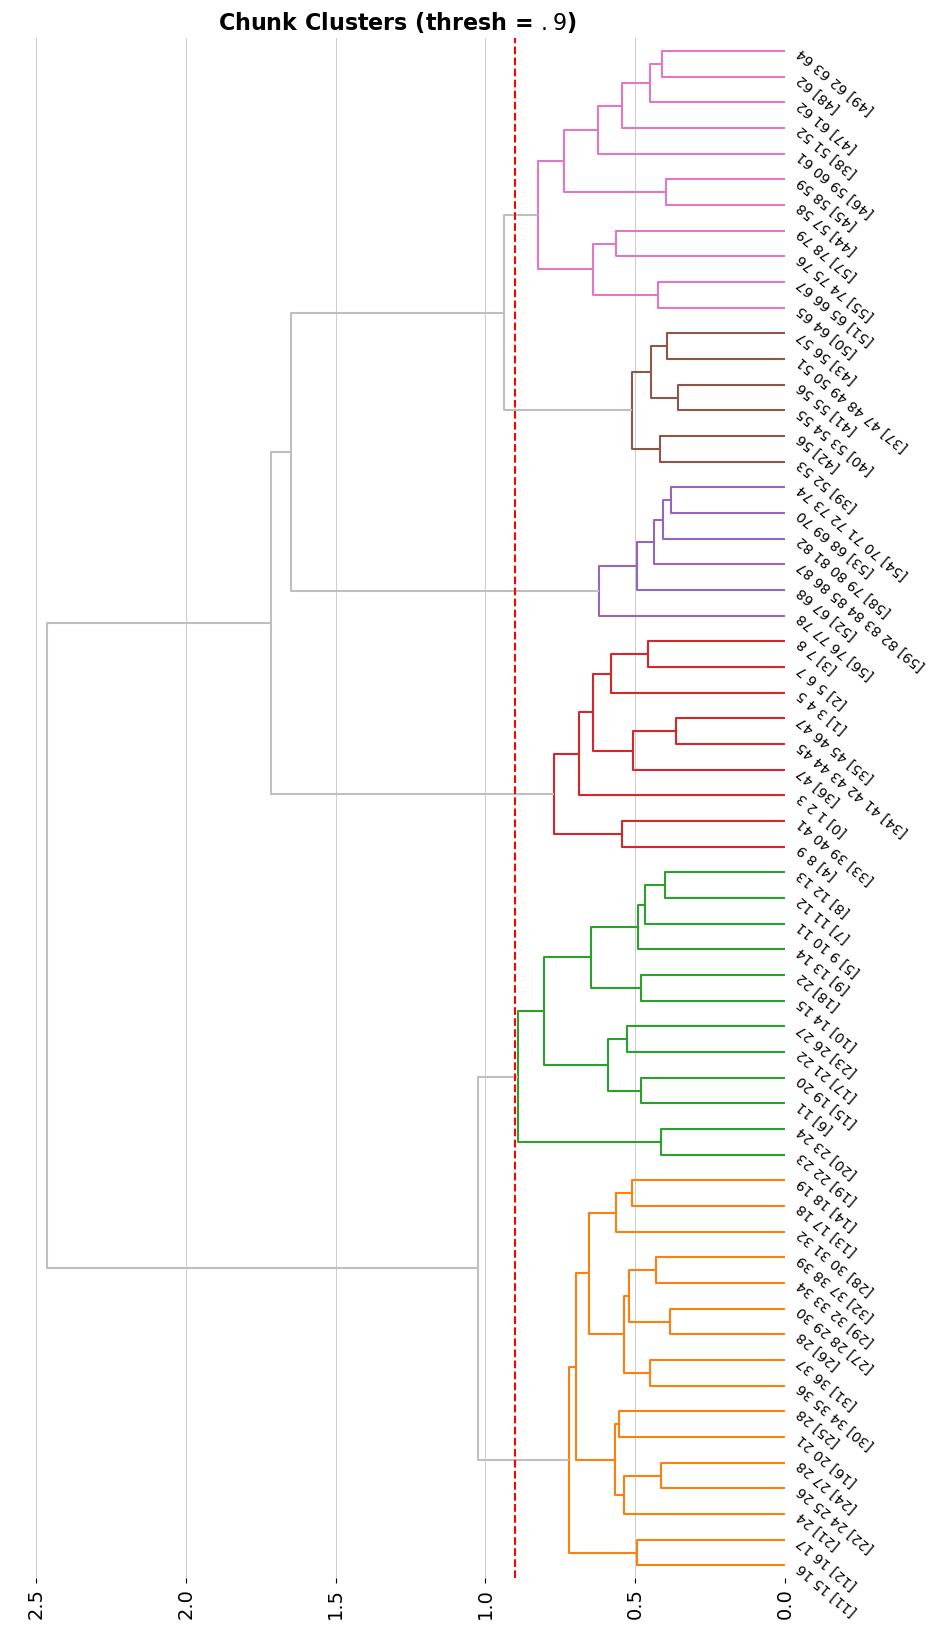

In [150]:
tfidf_hac = HAC(TFIDF_SIM, labels=CHUNK['short_label'].to_list())
tfidf_hac.get_sims()
tfidf_hac.get_tree()
tfidf_hac.color_thresh = .9
tfidf_hac.get_cluster_labels()
tfidf_hac.plot_tree()
plt.title(f"Chunk Clusters (thresh = {tfidf_hac.color_thresh}", y=1.01)
plt.xticks(rotation=90)
plt.yticks(rotation=140, fontsize=10)
plt.title("Chunk Clusters (thresh = $.9$)", fontsize=16, fontweight='heavy')
plt.show()

**Interpretation**

- Two main groups.
- Visual inspection shows this corresponds to the first and second halves of the book consistent with how the text is divided by all editions.
- The exception is the group containing chs 1-8 and 39-46 -- this group reflects the theme of creation, which begins both the first and second halves.
- This "echo" marks are thematic touch point.

## Apply cluseter labels to chunks and chapters

In [151]:
TOKEN

token_str term_str  chunk_num
chap_num line_num token_num                              
1        1        0              ARE'     are'          0
                  1                 U        u          0
                  2               XE'      xe'          0
                  3              OJER     ojer          0
                  4             TZIJ,     tzij          0
...                               ...      ...        ...
87       8725     7          K'iche',  k'iche'         59
         8726     0              Sta.      sta         59
                  1              Cruz     cruz         59
                  2                 u        u         59
                  3             b'i'.     b'i'         59

[29321 rows x 3 columns]

In [152]:
CHUNK['cluster_label'] = tfidf_hac.CLUSTER_LABELS
TOKEN['cluster_label'] = TOKEN.chunk_num.map(CHUNK.cluster_label) # BETTER THAN JOIN 
CHAP['cluster_label'] = (
    TOKEN
    .reset_index()
    .value_counts(['chap_num','cluster_label'])
    .unstack(fill_value=0)
    .idxmax(1)
)

In [153]:
# TOKEN.head()

## Create CLUSTER table

In [154]:
CLUSTER = CHUNK.cluster_label.value_counts().to_frame('n_chunks')

In [155]:
CLUSTER

,n_chunks
cluster_label,
1,16
2,12
6,11
3,9
5,6
4,6


In [156]:
CLUSTER_CHUNK = TOKEN.groupby(['cluster_label','chunk_num']).chunk_num.count().unstack(fill_value=0).astype(bool).astype(int)

In [157]:
# CLUSTER_CHUNK

In [158]:
# px.imshow(CLUSTER_CHUNK, color_continuous_scale=px.colors.diverging.Spectral, color_continuous_midpoint=0)

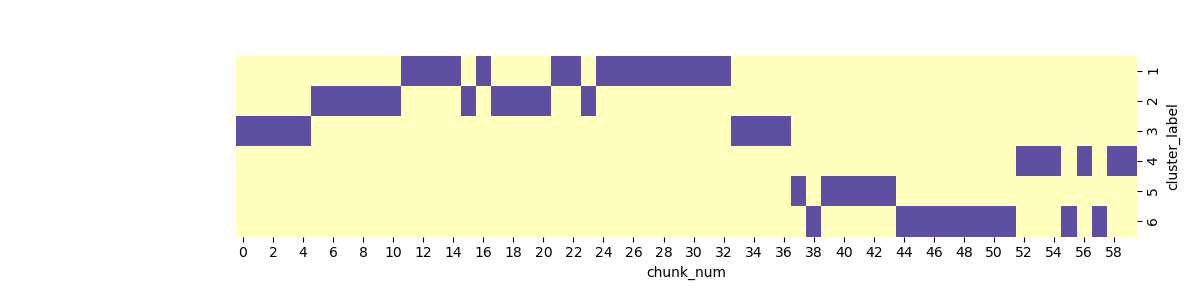

In [159]:
sns.clustermap(CLUSTER_CHUNK, 
                    cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=False, 
                     col_cluster=False,
                    figsize=(12,3))
plt.show()

## Add order to CLUSTER

In [160]:
labels = {}
ord = 0
for lbl in CHUNK.sort_index().cluster_label.values:
    if lbl not in labels:
        ord += 1
        labels[lbl] = ord

In [161]:
CLUSTER['ord'] = pd.Series(labels)

In [162]:
CLUSTER.sort_values('ord')

,n_chunks,ord
cluster_label,,
3,9,1
2,12,2
1,16,3
5,6,4
6,11,5
4,6,6


## Create CLUSTER_TFIDF model

**Cluster label glosses**

We find significant words for each cluster based on mean TFIDF grouping by cluster.

This also creates a model from the labels; that is, each cluster label is associated with a distribution over words.

In [163]:
label_col = "cluster_label"
CLUSTER_TFIDF = (
    TFIDF
    .join(CHUNK[label_col])
    .groupby(label_col)
    .mean()
)

In [164]:
CLUSTER_TFIDF.T.sample(5).sort_index().T.style.background_gradient(axis=None)

,amaq',kib',na'oj,taq,xsaqirik
cluster_label,,,,,
1,0.000000,0.047009,0.027076,0.011418,0.032337
2,0.000000,0.016944,0.021192,0.023381,0.000000
3,0.015551,0.012495,0.034193,0.013338,0.008989
4,0.046393,0.037803,0.017738,0.040286,0.000000
5,0.068721,0.043913,0.012395,0.032218,0.063326
6,0.116999,0.045295,0.036137,0.060875,0.000000


In [165]:
VOCAB['max_cluster'] = CLUSTER_TFIDF.idxmax()

In [166]:
CLUSTER['gloss'] = CLUSTER_TFIDF.idxmax(1)
CLUSTER['top_terms'] = CLUSTER_TFIDF.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [167]:
GT(CLUSTER.reset_index().sort_values('ord'))

cluster_label,n_chunks,ord,gloss,top_terms
3,9,1,b'it,"b'it, kaj, tz'aq, k'ajolom, alom, tz'aqol, b'itol"
2,12,2,k'ajolab',"k'ajolab', ati't, nu, tz'ikin, xb'alanke, xcha', che'"
1,16,3,kame,"kame, xib'alb'a, kik', samajel, junajpu, naqi, jolom"
5,6,4,k'ab'awil,"k'ab'awil, tulan, tojil, wakamik, xawi, tamub', chila'"
6,11,5,amaq',"amaq', b'alam, kitze, tojil, majukutaj, aq'ab', retal"
4,6,6,ajaw,"ajaw, nim, pop, k'iche', q'alel, ja, k'am"


## Assign glosses by hand

In [168]:
VOCAB[VOCAB.dh > VOCAB.dh.quantile(.9)].sort_values('dh', ascending=False).head(10)

,n,df,dfidf,dh,gloss,max_cluster
term_str,,,,,,
chi,747,83,5.636037,5.978804,None,4.0
u,1161,83,5.636037,5.977552,None,3.0
k'ut,836,84,4.252590,5.880417,None,2.0
wi,541,74,17.278270,5.784933,None,5.0
xa,577,74,17.278270,5.781503,None,2.0
are',331,77,13.564086,5.753629,None,1.0
ta,922,72,19.657332,5.724334,None,6.0
ki,821,77,13.564086,5.695681,None,6.0
ri,981,76,14.821215,5.654168,None,2.0


In [169]:
glosses = {
    "b'alam": "jaguar",
    "ajaw": "lord",
    "kaj": "sky",
    "xib'alb'a": "underworld (earth)",
    "q'apoj": "maiden, virgin",
    "sipakna": "Zipacna",
    "kati't": "grandmother",
    "kaqix": "macaw",
    "tojil": "Tojil",
    "kame": "death",
    "pop": "mat",
    "q'alel": "magistrate",
    "b'it": "shap(er)",
    "ch'o": "rat",
    "qati't": "grandmother",
    "le'": "generation",
    "amaq'": "nations",
    "k'ajolab'": "boys",
    "alom": "children",
    "chowen": "artisan"
}

for key, val in glosses.items():
    VOCAB.loc[key, 'gloss'] = val

In [170]:
VOCAB[~VOCAB.gloss.isna()]

,n,df,dfidf,dh,gloss,max_cluster
term_str,,,,,,
ajaw,137,34,46.086342,4.683535,lord,4.0
alom,17,11,32.818631,3.337175,children,3.0
amaq',125,24,44.591544,4.282757,nations,6.0
b'alam,193,31,46.151163,4.402985,jaguar,5.0
b'it,35,12,34.295772,3.218030,shap(er),3.0
ch'o,14,2,10.885887,0.940286,rat,NaN
chowen,27,5,20.605077,2.020510,artisan,NaN
k'ajolab',87,15,38.040794,3.323699,boys,2.0
kaj,91,31,46.151163,4.573153,sky,3.0


## Apply CLUSTER_TFIDF model to TOKEN

**Group by CHUNK**

In [171]:
CHUNK['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chunk_num')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHUNK['max_cluster_gloss'] = CHUNK.max_cluster.map(CLUSTER.gloss)

In [172]:
# CHUNK[['long_label', 'cluster_label', 'max_cluster','max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

No difference. 

**Group by CHAP**

In [173]:
CHAP['max_cluster'] = (
    TOKEN
    .join(CLUSTER_TFIDF.T, on='term_str')
    .dropna()
    .groupby('chap_num')[CLUSTER.index]
    .mean()
    .idxmax(1)
)
CHAP['max_cluster_gloss'] = CHAP.max_cluster.map(CLUSTER.gloss)

In [174]:
# CHAP[['chap_title', 'cluster_label', 'max_cluster', 'max_cluster_gloss']].style.background_gradient(cmap="YlGnBu")

# Principal Components

## Apply PCA to TFIDF

PCA sheds light on the relationship between the clusters.

We add $1$ to $k$ if odd to ensure we have pairs to display.

In [175]:
n_comps = 5
pca_engine = PCA(n_components=5)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'chunk_num'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

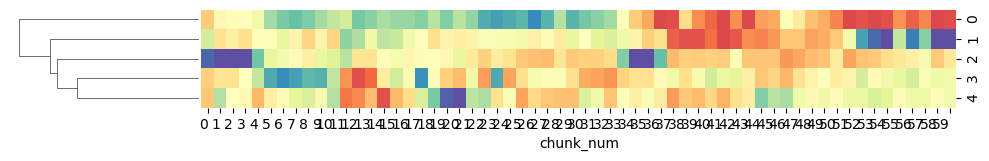

In [176]:
fig = sns.clustermap(PCAX.T,
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True,
                    figsize=(10,2))
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)

## Visualize compontents and clusters

In [177]:
X0 = CHUNK.join(PCAX)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.max_cluster_gloss,
        # symbol=X0.max_topic,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        template=px_template,
        height=850, width=950).show()
    

In [178]:
plot_pca(0,1)

In [179]:
plot_pca(2,3)

## Component Histograms

In [180]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='max_cluster_gloss',
           color='max_cluster_gloss',
           template=px_template,
           # height=400, width=600, 
           title=f'PC {i}').show()

In [181]:
for i in range(n_comps):
    comp_box(i)

# Topics

## Generate NMF model

Topic modeling with NMF gives further insight into the content of the clusters and how they combine in documents, i.e. units of narrative.

As a form of soft clustering, it lends insight into how each text segment relates to each cluster.

It also corroborates the clustering.

**Choose $k$ based on cluster threshold**

We choose $k$ based on the chosen cut-off threshold for the clustering above.

In [182]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

Create a list of columns for selection operations.

In [183]:
k_cols = [i for i in range(k)]
k_cols

[0, 1, 2, 3, 4, 5]

In [184]:
# NMF?

In [185]:
n_topic_terms = 10
n_topics = k
nmf_engine = NMF(n_components=n_topics, 
                 max_iter=10000, 
                 init='nndsvdar', # None, 'random', 'nndsvd', 'nndsvda', 'nndsvdar'
                 # alpha_W=.01,
                 # alpha_H=10,
                 solver='mu', 
                 beta_loss='kullback-leibler'
                )

THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)

PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
PHIX = PHI * np.log2(k/PHI.astype(bool).astype(int).sum())
PHIX = PHI

TOPIC = PHIX.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
TOPIC['gloss'] = PHI.idxmax(1)
TOPIC['gloss2'] = PHIX.idxmax(1)
# TOPIC['english'] = TOPIC.gloss.map(VOCAB.gloss)
# TOPIC['english2'] = TOPIC.gloss2.map(VOCAB.gloss)

In [186]:
THETA_SEQ = THETA_SIM.unstack().to_frame('w')
THETA_SEQ.index.names = ['tmp', 'chunk_num']
THETA_SEQ = THETA_SEQ.query("chunk_num == tmp + 1")
THETA_SEQ = THETA_SEQ.reset_index().drop(columns=['tmp']).set_index('chunk_num')
THETA_SEQ['d'] = 1 - THETA_SEQ.w

In [187]:
# THETA_SEQ.d.plot.bar(figsize=(15,2), rot=0);

In [188]:
TOPIC

,top_terms,gloss,gloss2
topic_id,,,
0,"xib'alb'a, kame, kik', samajel, jolom, cha'j, ...",xib'alb'a,xib'alb'a
1,"b'alam, kitze, tojil, majukutaj, amaq', ik'i, ...",b'alam,b'alam
2,"pop, ajaw, tinamit, nim, k'am, k'iche', ja, aj...",pop,pop
3,"b'it, kaj, tz'aq, b'itol, tz'aqol, ulew, k'ajo...",b'it,b'it
4,"nu, k'ajolab', xcha', ati't, in, a, wuqub', xu...",nu,nu
5,"kati't, tz'ikin, qati't, ix, kochoch, ya', je'...",kati't,kati't


In [189]:
# GT(TOPIC.sort_values('gloss2_ord')[['gloss2', 'english2', 'top_terms']])

In [190]:
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

## Compare topics to clusters

In [191]:
CHUNK['max_topic'] = THETA.idxmax(1)

In [192]:
CHUNK[['max_cluster_gloss', 'max_topic']].value_counts().unstack(fill_value=0).style.background_gradient()

max_topic,0,1,2,3,4,5
max_cluster_gloss,,,,,,
ajaw,0,0,8,0,0,0
amaq',0,7,0,0,0,2
b'it,0,1,0,8,0,0
k'ab'awil,0,6,0,0,0,0
k'ajolab',0,0,0,0,9,3
kame,12,0,0,0,1,3


In [193]:
# THETA.join(CHUNK[['long_label', 'max_topic']]).style.background_gradient(cmap="YlGnBu", axis=0)

## View topics over syuzhet: Thematic Structure

In [194]:
# CHUNK['short_label'].to_list()

## Graphic for Publication

In [195]:
w = k / 2
TOPIC['gloss2_ord'] = [4, 2, 5, 0, 1, 3]
TOPIC

,top_terms,gloss,gloss2,gloss2_ord
topic_id,,,,
0,"xib'alb'a, kame, kik', samajel, jolom, cha'j, ...",xib'alb'a,xib'alb'a,4
1,"b'alam, kitze, tojil, majukutaj, amaq', ik'i, ...",b'alam,b'alam,2
2,"pop, ajaw, tinamit, nim, k'am, k'iche', ja, aj...",pop,pop,5
3,"b'it, kaj, tz'aq, b'itol, tz'aqol, ulew, k'ajo...",b'it,b'it,0
4,"nu, k'ajolab', xcha', ati't, in, a, wuqub', xu...",nu,nu,1
5,"kati't, tz'ikin, qati't, ix, kochoch, ya', je'...",kati't,kati't,3


In [196]:
desired_order = list(TOPIC.sort_values('gloss2_ord').gloss2.values)
THETA.columns = TOPIC.gloss2
desired_order

["b'it", 'nu', "b'alam", "kati't", "xib'alb'a", 'pop']

In [197]:
THETA[desired_order].T

chunk_num,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
gloss2,,,,,,,,,,,,,,,,,,,,,
b'it,5.643771e-01,4.356011e-01,5.765745e-01,5.156947e-01,2.718818e-01,3.315270e-03,5.201167e-27,9.190497e-29,3.060200e-36,9.058175e-02,...,1.247639e-02,1.380647e-41,2.212035e-40,2.334814e-37,1.230609e-37,0.000003,6.895825e-24,7.211354e-02,1.020927e-39,1.853704e-19
nu,3.121096e-42,1.360259e-21,6.031379e-29,4.341406e-02,2.333511e-01,5.247244e-01,4.806061e-01,5.448168e-01,5.061456e-01,4.756375e-01,...,1.960448e-17,6.478884e-30,1.009029e-22,5.621523e-32,6.179372e-34,0.047378,1.524674e-18,6.311342e-03,9.580952e-34,3.665320e-26
b'alam,1.290009e-20,6.227926e-24,1.250323e-45,1.677423e-32,5.471384e-14,2.517351e-12,2.756588e-47,5.740697e-42,4.760804e-26,7.062531e-25,...,4.953999e-01,3.242777e-01,8.965748e-10,1.485885e-15,1.777623e-14,0.004727,1.320036e-14,6.940170e-06,2.941526e-02,5.631405e-05
kati't,3.162854e-40,1.429529e-01,1.019493e-22,5.683968e-19,4.076838e-15,1.723310e-27,1.510944e-23,6.546791e-17,2.324482e-09,7.182467e-11,...,3.772315e-06,1.356077e-03,1.176337e-29,1.442477e-17,2.594641e-26,0.000002,7.078175e-36,2.678694e-10,6.125760e-56,1.525386e-39
xib'alb'a,1.794183e-20,4.720644e-22,2.218600e-20,1.661390e-17,3.367943e-02,1.597990e-18,2.524439e-12,9.276389e-17,4.137961e-05,3.579678e-09,...,1.987742e-02,3.683867e-10,6.957234e-22,2.119760e-22,8.223268e-18,0.032746,9.788828e-33,1.579548e-15,1.047278e-33,2.910478e-30
pop,7.433022e-08,2.103734e-37,1.576373e-50,1.248551e-48,2.691277e-18,5.464938e-11,8.477767e-09,1.150253e-36,2.513826e-43,1.461354e-31,...,6.197864e-02,3.070545e-01,6.178404e-01,6.370189e-01,5.917877e-01,0.534703,5.014221e-01,5.403276e-01,5.495820e-01,4.802016e-01


In [198]:
THETA.T

chunk_num,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
gloss2,,,,,,,,,,,,,,,,,,,,,
xib'alb'a,1.794183e-20,4.720644e-22,2.218600e-20,1.661390e-17,3.367943e-02,1.597990e-18,2.524439e-12,9.276389e-17,4.137961e-05,3.579678e-09,...,1.987742e-02,3.683867e-10,6.957234e-22,2.119760e-22,8.223268e-18,0.032746,9.788828e-33,1.579548e-15,1.047278e-33,2.910478e-30
b'alam,1.290009e-20,6.227926e-24,1.250323e-45,1.677423e-32,5.471384e-14,2.517351e-12,2.756588e-47,5.740697e-42,4.760804e-26,7.062531e-25,...,4.953999e-01,3.242777e-01,8.965748e-10,1.485885e-15,1.777623e-14,0.004727,1.320036e-14,6.940170e-06,2.941526e-02,5.631405e-05
pop,7.433022e-08,2.103734e-37,1.576373e-50,1.248551e-48,2.691277e-18,5.464938e-11,8.477767e-09,1.150253e-36,2.513826e-43,1.461354e-31,...,6.197864e-02,3.070545e-01,6.178404e-01,6.370189e-01,5.917877e-01,0.534703,5.014221e-01,5.403276e-01,5.495820e-01,4.802016e-01
b'it,5.643771e-01,4.356011e-01,5.765745e-01,5.156947e-01,2.718818e-01,3.315270e-03,5.201167e-27,9.190497e-29,3.060200e-36,9.058175e-02,...,1.247639e-02,1.380647e-41,2.212035e-40,2.334814e-37,1.230609e-37,0.000003,6.895825e-24,7.211354e-02,1.020927e-39,1.853704e-19
nu,3.121096e-42,1.360259e-21,6.031379e-29,4.341406e-02,2.333511e-01,5.247244e-01,4.806061e-01,5.448168e-01,5.061456e-01,4.756375e-01,...,1.960448e-17,6.478884e-30,1.009029e-22,5.621523e-32,6.179372e-34,0.047378,1.524674e-18,6.311342e-03,9.580952e-34,3.665320e-26
kati't,3.162854e-40,1.429529e-01,1.019493e-22,5.683968e-19,4.076838e-15,1.723310e-27,1.510944e-23,6.546791e-17,2.324482e-09,7.182467e-11,...,3.772315e-06,1.356077e-03,1.176337e-29,1.442477e-17,2.594641e-26,0.000002,7.078175e-36,2.678694e-10,6.125760e-56,1.525386e-39


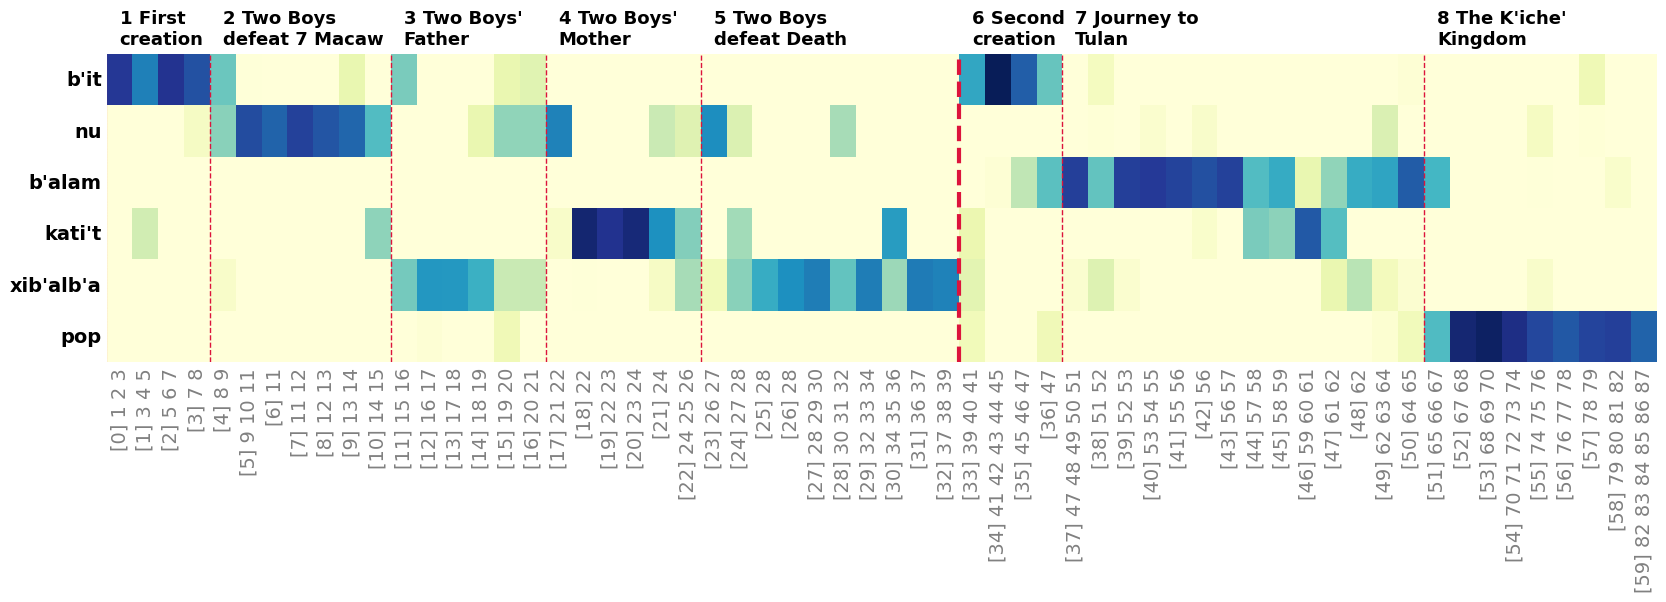

In [199]:
plt.figure(figsize=(20, 4))
ax = sns.heatmap(THETA[desired_order].T, cmap="YlGnBu", cbar=None)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(fontsize=14, color='gray')
plt.yticks(fontsize=14, fontweight='heavy')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.set_xticklabels(CHUNK['short_label'].to_list(), rotation=90)
plt.yticks(rotation=0)

# Add chapter breaks
chapters = {
    (0,2) :  "1 First\ncreation",
    (4,3): "2 Two Boys\ndefeat 7 Macaw",
    (11,4): "3 Two Boys'\nFather",
    (17,3): "4 Two Boys'\nMother",
    (23,2): "5 Two Boys\ndefeat Death",
    (33,2): "6 Second\ncreation",
    (37,4): "7 Journey to\nTulan",
    (51,5): "8 The K'iche'\nKingdom"
}

for x, y in chapters:
    lw = 1
    if x == 0:
        lw = .1
    elif x == 33:
        lw = 3
    ax.axvline(x, color='crimson', ls='--', lw=lw)
    ax.annotate(chapters[(x,y)], xy=(x,y), xytext=(x+.5, -.5), ha='left', fontsize=13, fontweight='bold', va='center')


plt.savefig("topic-heatmap.svg")
plt.savefig("topic-heatmap.png")
plt.show()

In [200]:
chap_chunks = [ch[0] for ch in chapters]
CHUNK_TO_CHAP.loc[chap_chunks[1:]].reset_index()[['chunk_num', 'chap_num', 'chap_title']].set_index(['chunk_num', 'chap_num'])

NameError: name 'CHUNK_TO_CHAP' is not defined

In [ ]:
CHUNK_TO_CHAP.query("chap_num == 41")

,,chap_num,chap_title,chap_label
chunk_id,chap_ord,,,
34,2,41,The Creation of Humanity,41: The Creation of Humanity
35,0,41,The Creation of Humanity,41: The Creation of Humanity


## Classify chapters with NMF model

**Model by THETA**

In [ ]:
CHAP_TOPIC_THETA = (
    TOKEN
    .join(THETA, on='chunk_num')[THETA.columns]
    .groupby(['chap_num'])
    .mean()
)

In [ ]:
CHAP_TOPIC_THETA

,b'alam,xib'alb'a,ajaw,kaj,kaqix,kati't
chap_num,,,,,,
1,8.355096e-21,1.578548e-25,1.164955e-10,5.225814e-01,7.615252e-25,4.580341e-37
2,8.355096e-21,1.578548e-25,1.164955e-10,5.225814e-01,7.615252e-25,4.580341e-37
3,2.341015e-12,3.811419e-21,3.688416e-11,5.015675e-01,1.631319e-20,3.274321e-12
4,3.425614e-12,5.577187e-21,3.095943e-26,4.918317e-01,2.387078e-20,4.791323e-12
5,1.768964e-12,2.880158e-21,1.598724e-26,5.044612e-01,1.232672e-20,2.474208e-12
...,...,...,...,...,...,...
83,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39
84,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39
85,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39


In [ ]:
# plt.figure(figsize=(15, 15))
# sns.heatmap(CHAP_TOPIC_THETA.T.corr(), cmap='YlGnBu');

In [ ]:
# sns.clustermap(CHAP_TOPIC_THETA.T.corr(), cmap='YlGnBu', robust=True, col_cluster=False, row_cluster=True, cbar_pos=None, figsize=(10, 5));

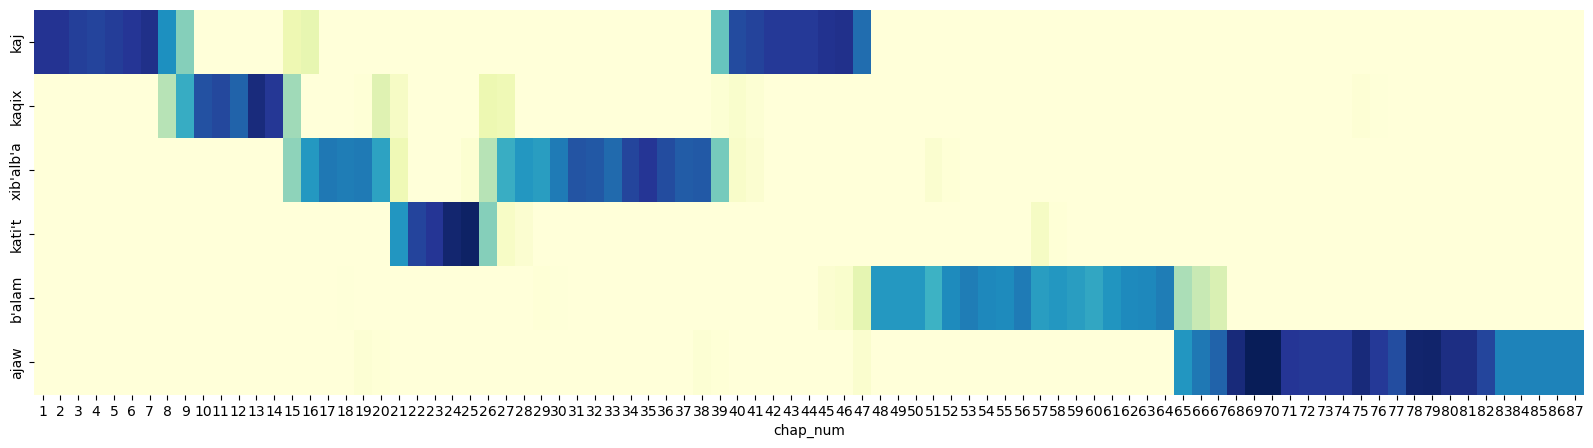

In [ ]:
plt.figure(figsize=(20, 5))
sns.heatmap(CHAP_TOPIC_THETA.T.loc[desired_order], cmap='YlGnBu', cbar=None)
plt.show()

**Model by PHI**

In [ ]:
CHAP_TOPIC = (
    TOKEN
    .join(PHI.T, on='term_str')
    .dropna()
    .fillna(0)
    .groupby(['chap_num'])[k_cols]
    .mean()
)

In [ ]:
CHAP_TOPIC

,0,1,2,3,4,5
chap_num,,,,,,
1,0.041567,0.029583,0.046872,0.094041,0.021338,0.019187
2,0.051224,0.042485,0.040296,0.082546,0.036552,0.031594
3,0.044834,0.034091,0.032472,0.092561,0.038887,0.029500
4,0.047181,0.029728,0.022038,0.057190,0.040178,0.052164
5,0.057731,0.044899,0.025931,0.086828,0.041561,0.041118
...,...,...,...,...,...,...
78,0.085122,0.040895,0.098824,0.053991,0.027474,0.027734
79,0.065680,0.034810,0.085089,0.055569,0.025961,0.025859
80,0.102789,0.042667,0.079016,0.038600,0.023430,0.022327


In [ ]:
# sns.clustermap(CHAP_TOPIC.T.corr(), cmap='YlGnBu', col_cluster=False, robust=False, cbar_pos=None, figsize=(10, 2));
# CHAP_TOPIC.T

In [ ]:
from sklearn.preprocessing import normalize

In [ ]:
# plt.figure(figsize=(10,2))
# sns.heatmap(CHAP_TOPIC[desired_order].T, cmap='YlGnBu', cbar=None);

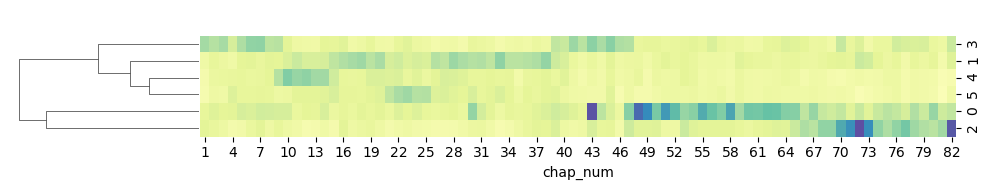

In [ ]:
sns.clustermap(CHAP_TOPIC.T,
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                       robust=False,
                    figsize=(10,2));

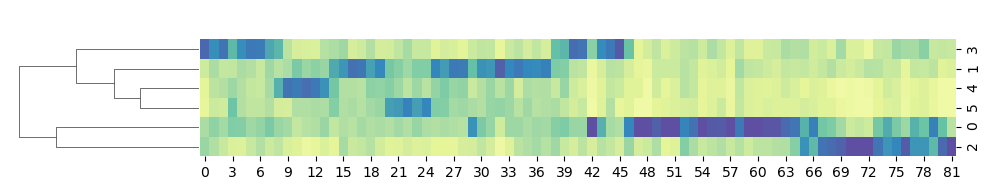

In [ ]:
sns.clustermap(normalize(CHAP_TOPIC.T, 'l2', axis=0),
                     cmap='Spectral', method='ward',
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                       robust=True,
                    figsize=(10,2));

In [ ]:
CHAP['max_topic'] = CHAP_TOPIC[k_cols].idxmax(1)
CHAP['max_topic_theta'] = CHAP_TOPIC_THETA.idxmax(1)
CHAP['max_topic_gloss'] = CHAP.max_topic.map(TOPIC.gloss)

In [ ]:
CHAP[['max_cluster_gloss', 'max_topic_theta']].value_counts().unstack(fill_value=0).style.background_gradient()

max_topic_theta,ajaw,b'alam,kaj,kaqix,kati't,xib'alb'a
max_cluster_gloss,,,,,,
ajaw,17,1,0,0,0,0
b'alam,1,16,2,0,0,1
kaj,0,0,15,0,0,0
kaqix,0,0,0,6,0,0
q'apoj,0,0,0,0,5,3
xib'alb'a,0,0,0,0,1,14


# Sequential correlations

## Sequential Correlations of Chunks

We apply a simplified model of resonance.

In [ ]:
THETA = THETA[desired_order]

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Compute color range for centered colormap
z = THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Gloss × Chunk Heatmap", "Chunk Distance from Previous")
)

# Heatmap
heatmap = go.Heatmap(
    z=z,
    x=THETA.T.columns,
    y=THETA.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot of distances (by similarity)
bar = go.Bar(
    x=THETA_SEQ.index,  # assuming chunk_num is the index
    y=THETA_SEQ['d'],
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=350,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=14)
fig.update_yaxes(title_text="gloss", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)
fig.update_xaxes(title_text="chunk_num", row=2, col=1)

fig.show()

Evidence for Br and Re break for Part IV -- Midway through Ch. 57.

In [ ]:
CHUNK_CHAP_MATRIX[[52]].dropna().join(CHAP.chap_title)

,52,chap_title
chap_num,,
65,142.0,The Sons of the Progenitors Journey to Tulan
66,109.0,The Sons Receive Authority to Rule
67,237.0,The Migrations of the Quichés


In [ ]:
CHUNK_CHAP_MATRIX[[38]].dropna().join(CHAP.chap_title)

,38,chap_title
chap_num,,
47,18.0,The Creation of the Mothers of the Quiché Nation
48,33.0,The Arrival at Tulan
49,125.0,The Progenitors Receive their Gods
50,262.0,The Progenitors Leave Tulan
51,51.0,The Nations Ask for their Fire


In [ ]:
CHUNK_CHAP_MATRIX[[34]].dropna().join(CHAP.chap_title)

,34,chap_title
chap_num,,
39,236.0,The Miraculous Maize of Hunahpu and Xbalanque
40,197.0,"The Apotheosis of the Sun, Moon, and Stars"
41,56.0,The Creation of Humanity


## Sequential Correlation among Chapters

In [ ]:
CHAP_TOPIC_THETA_SIM = pd.DataFrame(cosine_similarity(CHAP_TOPIC_THETA), index=CHAP_TOPIC_THETA.index, columns=CHAP_TOPIC_THETA.index).stack().to_frame('w')
CHAP_TOPIC_THETA_SIM.index.names = ['tmp', 'chap_id']
CHAP_TOPIC_THETA_SIM = CHAP_TOPIC_THETA_SIM.query("chap_id == tmp + 1").reset_index().set_index('chap_id').drop(columns=['tmp'])
CHAP_TOPIC_THETA_SIM['d'] = 1 - CHAP_TOPIC_THETA_SIM.w
# CHAP_TOPIC_THETA_SIM

In [ ]:
CHAP_TOPIC_THETA

,b'alam,xib'alb'a,ajaw,kaj,kaqix,kati't
chap_num,,,,,,
1,8.355096e-21,1.578548e-25,1.164955e-10,5.225814e-01,7.615252e-25,4.580341e-37
2,8.355096e-21,1.578548e-25,1.164955e-10,5.225814e-01,7.615252e-25,4.580341e-37
3,2.341015e-12,3.811419e-21,3.688416e-11,5.015675e-01,1.631319e-20,3.274321e-12
4,3.425614e-12,5.577187e-21,3.095943e-26,4.918317e-01,2.387078e-20,4.791323e-12
5,1.768964e-12,2.880158e-21,1.598724e-26,5.044612e-01,1.232672e-20,2.474208e-12
...,...,...,...,...,...,...
83,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39
84,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39
85,2.717445e-13,4.859681e-35,3.930432e-01,8.163507e-22,3.870282e-25,2.449616e-39


In [ ]:
# Compute color range for centered colormap

# Create subplot layout
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.6, 0.4],
    vertical_spacing=0.1,
    subplot_titles=("Glosses over Chpaters", "Chapter Distance from Previous")
)

# Heatmap
z = CHAP_TOPIC_THETA.T.values
zmin, zmax = z.min(), z.max()
midpoint = 0
vmax = max(abs(zmin - midpoint), abs(zmax - midpoint))
zmin, zmax = midpoint - vmax, midpoint + vmax
heatmap = go.Heatmap(
    z=z,
    x=CHAP_TOPIC.T.columns,
    y=TOPIC.gloss, #CHAP_TOPIC.T.index,
    colorscale='Spectral',
    zmin=zmin,
    zmax=zmax,
    showscale=False
)
fig.add_trace(heatmap, row=1, col=1)

# Barplot
X = CHAP_TOPIC_THETA_SIM.join(CHAP).reset_index()
bar = go.Bar(
    x = X.chap_id, 
    y = X.d, #.rolling(2).mean(), 
    marker_color='royalblue'
)
fig.add_trace(bar, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=330,
    width=1000,
    margin=dict(t=60),
    showlegend=False
)

fig.update_annotations(font_size=16)

# fig.update_yaxes(title_text="chapter", row=1, col=1)
fig.update_yaxes(title_text="topic", row=1, col=1)
fig.update_yaxes(title_text="d", row=2, col=1)

fig.update_xaxes(title_text="chapter number", row=2, col=1)

fig.show()

In [ ]:
chap_nums = 8, 9, 10, 15, 16, 21, 26, 27, 39, 40, 48, 65
part_num = 1
for i, chap_num in enumerate(chap_nums):
    if i == 0 or chap_num > chap_nums[i-1] + 1:
        part_num += 1
        print('Part', part_num) #, '-' * 80)
    print("  ", str(chap_num).zfill(2), CHAP.loc[chap_num].chap_title)

Part 2
   08 The Fall of the Effigies of Carved Wood
   09 The Pride of Seven Macaw Before the Dawn
   10 The Fall of Seven Macaw and His Sons
Part 3
   15 The Tale of the Father of Hunahpu and Xbalanque
   16 The Deeds of One Hunahpu and Seven Hunahpu Above Xibalba
Part 4
   21 Lady Blood and the Miracle of the Maize
Part 5
   26 The Summons of Hunahpu and Xbalanque to Xibalba
   27 Hunahpu and Xbalanque Receive the Summons to Xibalba
Part 6
   39 The Miraculous Maize of Hunahpu and Xbalanque
   40 The Apotheosis of the Sun, Moon, and Stars
Part 7
   48 The Arrival at Tulan
Part 8
   65 The Sons of the Progenitors Journey to Tulan


In [ ]:
CHAP['wdiff'] = CHAP_TOPIC_THETA_SIM.d
CHAP['new'] = (CHAP_TOPIC_THETA_SIM.d > .25).astype(bool)
CHAP.loc[1, 'new'] = True

# Assign PART titles

In [ ]:
PART = CHAP.loc[CHAP.new == True, ['chap_title']].reset_index()
PART.index.name = 'part_num'
PART = PART.reset_index()
PART.part_num = PART.part_num + 1
PART = PART.set_index('part_num')
PART = PART.sort_index()

In [ ]:
PART

,chap_num,chap_title
part_num,,
1,1,Preamble
2,15,The Tale of the Father of Hunahpu and Xbalanque
3,21,Lady Blood and the Miracle of the Maize
4,27,Hunahpu and Xbalanque Receive the Summons to X...
5,39,The Miraculous Maize of Hunahpu and Xbalanque
6,48,The Arrival at Tulan
7,65,The Sons of the Progenitors Journey to Tulan


In [ ]:
CHAP['part_num'] = PART.reset_index().set_index('chap_num').part_num
CHAP.part_num = CHAP.part_num.ffill()

In [ ]:
CHAP[['chap_title', 'chunk_nums', 'max_cluster', 'max_topic_theta', 'part_num', 'wdiff', 'new']].style.background_gradient(axis=0)

,chap_title,chunk_ids,max_cluster,max_topic_theta,part_num,wdiff,new
chap_num,,,,,,,
1,Preamble,1,6.000000,kaj,1.000000,nan,True
2,The Primordial World,1,6.000000,kaj,1.000000,0.000000,False
3,The Creation of the Earth,"1,2",6.000000,kaj,1.000000,0.000000,False
4,The Creation of the Animals,2,6.000000,kaj,1.000000,0.000000,False
5,The Fall of the Animals,"2,3",6.000000,kaj,1.000000,0.000000,False
6,The Creation of the Mud Person,3,6.000000,kaj,1.000000,0.000000,False
7,The Creation of the Effigies of Carved Wood,"3,4",6.000000,kaj,1.000000,0.000000,False
8,The Fall of the Effigies of Carved Wood,"4,5",6.000000,kaj,1.000000,0.086774,False
9,The Pride of Seven Macaw Before the Dawn,"5,6",1.000000,kaqix,1.000000,0.148644,False


In [ ]:
CLUSTER

,n_chunks,ord,gloss,top_terms
cluster_label,,,,
4,15,5,b'alam,"b'alam, amaq', tojil, kitze, majukutaj, k'ab'a..."
3,14,3,xib'alb'a,"xib'alb'a, junajpu, kame, xecha', xcha', k'ajo..."
6,10,1,kaj,"kaj, aj, b'it, ulew, tz'aq, winaq, b'i'"
2,8,4,q'apoj,"q'apoj, che', junajpu, chowen, ati't, b'atz', ..."
5,8,6,ajaw,"ajaw, ajawab', pop, aj, tinamit, ja, k'iche'"
1,5,2,kaqix,"kaqix, sipakna, k'ajolab', wuqub', jul, much', o'"


In [ ]:
TOPIC

,top_terms,gloss,gloss2,english,english2,gloss2_ord
topic_id,,,,,,
0,"b'alam, amaq', tojil, kitze, majukutaj, b'i', ...",b'alam,b'alam,jaguar,jaguar,4
1,"xib'alb'a, kame, junajpu, kik', xcha', b'a, wu...",xib'alb'a,xib'alb'a,underworld (earth),underworld (earth),2
2,"ajaw, ja, ajawab', aj, pop, tinamit, nim, k'ic...",ajaw,ajaw,lord,lord,5
3,"kaj, aj, b'it, winaq, ulew, tz'aq, alom, k'ajo...",kaj,kaj,sky,sky,0
4,"kaqix, k'ajolab', sipakna, wuqub', jul, kab'ra...",kaqix,kaqix,macaw,macaw,1
5,"kati't, qati't, ch'o, ati't, chowen, b'atz', c...",kati't,kati't,grandmother,grandmother,3


In [ ]:
PART

,chap_num,chap_title
part_num,,
1,1,Preamble
2,15,The Tale of the Father of Hunahpu and Xbalanque
3,21,Lady Blood and the Miracle of the Maize
4,27,Hunahpu and Xbalanque Receive the Summons to X...
5,39,The Miraculous Maize of Hunahpu and Xbalanque
6,48,The Arrival at Tulan
7,65,The Sons of the Progenitors Journey to Tulan


# Conclusion

## TOPICS 

- The Parts
  - 7 Parts 
  - Highlighting the role of Blood Woman
  - Optional Preamble and Coda
  - Each part is distinguished temporally and ontologically
- Parts in relation to chronotope
  - Before and after the dawn
  - Above and below the world
  - Transitions: ends adumbrate beginning in the manner of the Haab
- Thematic structure
  - Themes
    - K'aj: Creation
    - B'alam: Religion, Spiritual Authority
    - Ajaw: Rulership, Temporal Power
    - Xib'alb'a: The Underworld, Destruction, Two Boys and their parents
    - Kaqix: 7 Macaw
    - Katoi't: Blood Woman
  - Sequentially
    - Each major part has three parts: Creation, Part A, and Part B
    - The sequence matters: We go from the creation of the world to the creation of society
    - The sequence charts a lineage from the K'iche' kings to the creator gods. 
  - Structurally
    - Two major parts corresponding to before and after the first dawn
    - See PCA
- Entropy
  - The goings on in Xibalba have the moist variability
- General

# Save

In [ ]:
savers = [
    (TFIDF, 'TFIDF'),
    (TFIDF_SIM, 'TFIDF_SIM'),
    (CHAP, 'CHAP_MOD'),
    (CHUNK, 'CHUNK_MOD'),
    (CHUNK_TO_CHAP, 'CHUNK_TO_CHAP'),
    (CHAP_TOPIC, 'CHAP_TOPIC')
]

In [ ]:
for saver in savers:
    obj = saver[0]
    slug = saver[1]
    obj.to_csv(f"christenson-{slug}.csv", index=True)

# Entropy

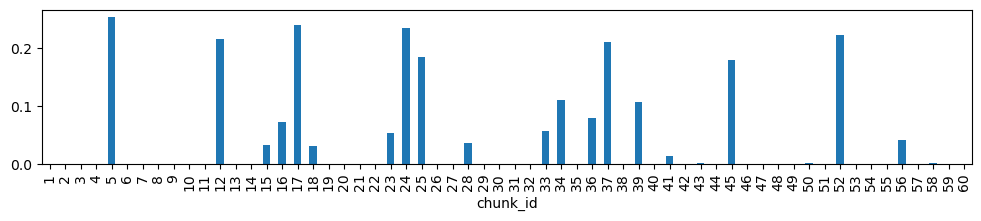

In [ ]:
# M = CHAP_TOPIC.T
# M = CHAP_TOPIC_THETA.T
M = THETA.T
# M = PHI.T
P = (M / M.sum())
H = P * np.log2(1/P)
H.std().round(3).plot.bar(figsize=(12,2));

In [ ]:
def compute_entropy(X):
    P = X / X.sum()
    H = (P * np.log2(1/P)).sum()
    Hmax =  1/len(X) * np.log2(len(X))
    R = 1 - H/Hmax
    R.plot.barh(title=f'R sum: {R.mean()}')
    # return R.mean()

In [ ]:
# R

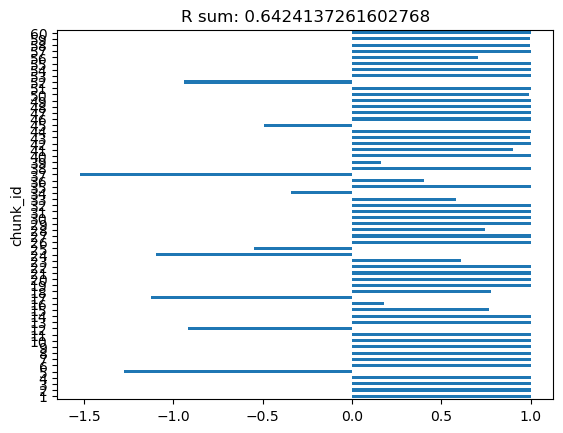

In [ ]:
compute_entropy(THETA.T)

In [ ]:
# R.mean()

```csv
60 | 0.4262047671312379
30 | 0.34843081567879547
```

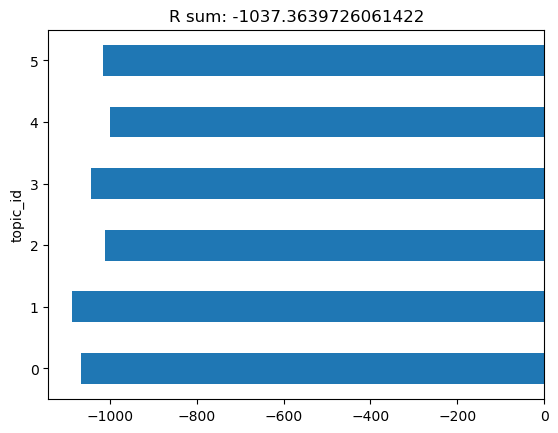

In [ ]:
compute_entropy(PHI.T)

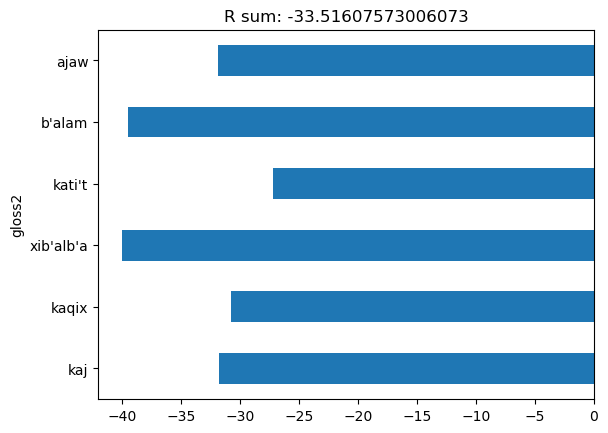

In [ ]:
compute_entropy(THETA)

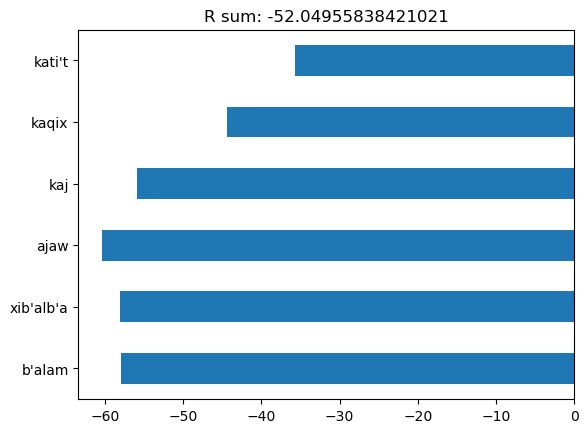

In [ ]:
compute_entropy(CHAP_TOPIC_THETA)

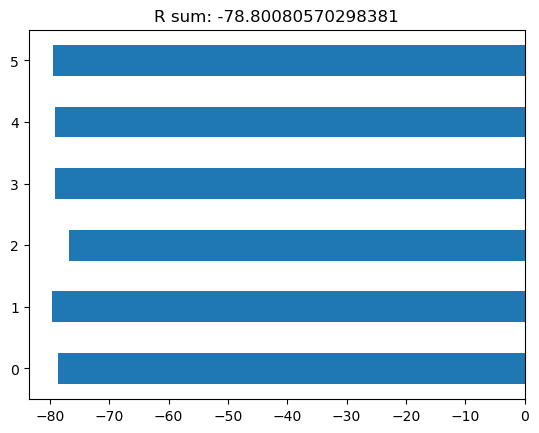

In [ ]:
compute_entropy(CHAP_TOPIC)